In [24]:
#Install & Import Required Libraries
!pip install mysql-connector-python --quiet

import pandas as pd
import numpy as np
import mysql.connector
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
import lightgbm as lgb
from datetime import datetime

In [25]:
#Connect to MySQL & Load Tables
!pip install mysql-connector-python --quiet
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="18.136.157.135",
    port=3306,
    user="dm_team1",
    password="DM!$Team&279@20!",
    database="project_banking"
)

acct = pd.read_sql("SELECT * FROM Cust_Account", conn)
enq = pd.read_sql("SELECT * FROM Cust_Enquiry", conn)
demo = pd.read_sql("SELECT * FROM Cust_Demographics", conn)
conn.close()
TODAY = datetime.today()

In [26]:
#Fix Invalid Dates & Convert Columns
# Convert date columns safely
for col in ['dt_opened','upload_dt','opened_dt','last_paymt_dt','closed_dt',
            'reporting_dt','paymt_str_dt','paymt_end_dt']:
    if col in acct.columns:
        acct[col] = pd.to_datetime(acct[col], errors='coerce')

if 'enquiry_dt' in enq.columns:
    enq['enquiry_dt'] = pd.to_datetime(enq['enquiry_dt'], errors='coerce')

if 'dob' in demo.columns:
    demo['dob'] = pd.to_datetime(demo['dob'], errors='coerce')

# Numeric cleaning
for col in ['high_credit_amt','cur_balance_amt','amt_past_due','creditlimit',
            'cashlimit','actualpaymentamount','rateofinterest']:
    if col in acct.columns:
        acct[col] = pd.to_numeric(acct[col], errors='coerce')

# Enquiry amount cleanup
if 'enq_amt' in enq.columns:
    enq['enq_amt'] = pd.to_numeric(
        enq['enq_amt'].astype(str).str.replace(r'[^0-9]', "", regex=True),
        errors="coerce"
    )

In [27]:
for df in [acct, enq, demo]:
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].replace("0000-00-00", np.nan)

In [28]:
#Parse & Convert Payment History Strings
def parse_payment_history_string(s):
    """Parse payment history: 3-char per month."""
    if not isinstance(s, str):
        return []
    s = s.replace('"','').replace("'","")
    blocks = [s[i:i+3] for i in range(0, len(s), 3) if len(s[i:i+3])==3]

    out = []
    for b in blocks:
        if b == "STD" or b == "000":
            out.append(0)
        elif b == "XXX":
            out.append(np.nan)
        else:
            digits = ''.join([ch for ch in b if ch.isdigit()])
            out.append(int(digits) if digits else np.nan)
    return out


def series_from_ph_col(series, orientation="right"):
    parsed = series.fillna("").astype(str).apply(parse_payment_history_string)
    if orientation == "right":
        return parsed
    else:
        return parsed.apply(lambda lst: list(reversed(lst)))

In [29]:
def extract_ph_features(parsed_series, prefix):
    """Turn parsed payment history list into feature columns."""
    rows = []
    for lst in parsed_series:
        arr = np.array([x for x in lst if not pd.isna(x)], dtype=float)
        if len(arr)==0:
            rows.append({
                f"{prefix}_worst": 0,
                f"{prefix}_mean": 0,
                f"{prefix}_len": 0,
                f"{prefix}_cnt_30p": 0,
                f"{prefix}_cnt_60p": 0,
                f"{prefix}_cnt_90p": 0,
                f"{prefix}_recent3_max": 0,
                f"{prefix}_recent6_max": 0,
                f"{prefix}_recent12_max": 0,
                f"{prefix}_first_30_month": np.nan,
                f"{prefix}_months_since_last_30": np.nan
            })
            continue

        worst = arr.max()
        mean = arr.mean()
        ln   = len(arr)
        cnt30 = (arr>=30).sum()
        cnt60 = (arr>=60).sum()
        cnt90 = (arr>=90).sum()

        recent3  = arr[-3:]  if ln>=3  else arr
        recent6  = arr[-6:]  if ln>=6  else arr
        recent12 = arr[-12:] if ln>=12 else arr

        rec3 = np.nanmax(recent3)  if len(recent3)>0 else 0
        rec6 = np.nanmax(recent6)  if len(recent6)>0 else 0
        rec12 = np.nanmax(recent12) if len(recent12)>0 else 0

        # months until first 30+
        idx_first = None
        for idx, val in enumerate(arr[::-1], start=1):
            if val>=30:
                idx_first=idx
                break

        # months since last 30+
        idx_last=None
        for idx,val in enumerate(arr[::-1],start=0):
            if val>=30:
                idx_last=idx
                break

        rows.append({
            f"{prefix}_worst": worst,
            f"{prefix}_mean": mean,
            f"{prefix}_len": ln,
            f"{prefix}_cnt_30p": cnt30,
            f"{prefix}_cnt_60p": cnt60,
            f"{prefix}_cnt_90p": cnt90,
            f"{prefix}_recent3_max": rec3,
            f"{prefix}_recent6_max": rec6,
            f"{prefix}_recent12_max": rec12,
            f"{prefix}_first_30_month": idx_first,
            f"{prefix}_months_since_last_30": idx_last
        })

    return pd.DataFrame(rows)

In [30]:
def build_features_orientation(orientation="right"):
    print("Processing orientation:", orientation)

    # Parse payment histories
    ph1 = series_from_ph_col(acct['paymenthistory1'], orientation)
    ph2 = series_from_ph_col(acct['paymenthistory2'], orientation)

    ph1_f = extract_ph_features(ph1, "ph1")
    ph2_f = extract_ph_features(ph2, "ph2")

    acct_local = acct.reset_index(drop=True)
    acct_local = pd.concat([acct_local, ph1_f, ph2_f], axis=1)

    # DPD & attribute aggregation
    agg = {
        'num_acct': ('customer_no','size'),
        'total_balance': ('cur_balance_amt','sum'),
        'avg_balance': ('cur_balance_amt','mean'),
        'total_creditlimit': ('creditlimit','sum'),
        'avg_creditlimit': ('creditlimit','mean'),
        'total_high_credit': ('high_credit_amt','sum')
    }

    # Add aggregated ph stats
    for col in acct_local.columns:
        if any(k in col for k in ['ph1_','ph2_']):
            agg[f"sum_{col}"] = (col,'sum')
            agg[f"mean_{col}"] = (col,'mean')
            agg[f"max_{col}"] = (col,'max')

    # last payment difference
    if 'last_paymt_dt' in acct_local.columns and 'opened_dt' in acct_local.columns:
        acct_local['diff_lastpay_open'] = (
            pd.to_datetime(acct_local['last_paymt_dt'], errors='coerce') -
            pd.to_datetime(acct_local['opened_dt'], errors='coerce')
        ).dt.days
        agg['sum_diff_lastpay_open'] = ('diff_lastpay_open','sum')
        agg['mean_diff_lastpay_open'] = ('diff_lastpay_open','mean')

    cust_agg = acct_local.groupby("customer_no").agg(**agg).reset_index()

    # Utilisation
    cust_agg['ratio_balance_to_limit'] = (
        cust_agg['total_balance'] /
        (cust_agg['total_creditlimit'] + 1e-9)
    )

    # Enquiry aggregation
    enq_local = enq.copy()
    enq_local['days_from_today'] = (
        TODAY - pd.to_datetime(enq_local['enquiry_dt'], errors='coerce')
    ).dt.days

    enq_agg = enq_local.groupby("customer_no").agg(
        cnt_enq=('customer_no','size'),
        enq_90=('days_from_today', lambda x:(x<=90).sum()),
        enq_365=('days_from_today', lambda x:(x<=365).sum()),
        max_enq_amt=('enq_amt', 'max')
    ).reset_index()

    # Demo processing
    demo_local = demo.copy()
    if 'dob' in demo_local.columns:
        demo_local['age'] = (TODAY - demo_local['dob']).dt.days // 365

    for c in demo_local.columns:
        if demo_local[c].dtype == object and c not in ['customer_no','Bad_label']:
            demo_local[c] = demo_local[c].fillna("missing").astype(str)
            try:
                demo_local[c] = LabelEncoder().fit_transform(demo_local[c])
            except:
                pass

    # Merge all
    df = demo_local.merge(cust_agg, on="customer_no", how="left")\
                   .merge(enq_agg, on="customer_no", how="left")\
                   .fillna(0)

    df = df[df['Bad_label'].notna()]
    df['Bad_label'] = df['Bad_label'].astype(int)

    return df

In [31]:
#Train-Validation Split
from sklearn.model_selection import train_test_split

def quick_xgb_auc(df):
    X = df.drop(columns=['customer_no','Bad_label'], errors='ignore')
    y = df['Bad_label']

    # remove constant columns
    nunique = X.nunique()
    X = X.drop(columns=nunique[nunique <= 1].index.tolist(), errors='ignore')

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval   = xgb.DMatrix(X_val, label=y_val)

    scale_pos = (len(y_train)-y_train.sum()) / (y_train.sum()+1e-9)

    params = {"objective":"binary:logistic", "eval_metric":"auc",
              "eta":0.05, "max_depth":6, "scale_pos_weight":scale_pos}

    model = xgb.train(params, dtrain, num_boost_round=250,
                      evals=[(dval,"val")],
                      early_stopping_rounds=50,
                      verbose_eval=False)

    auc = roc_auc_score(y_val, model.predict(dval))
    return auc, model

In [32]:
#Orientation Processing
df_right = build_features_orientation("right")
auc_right, model_r = quick_xgb_auc(df_right)

df_left = build_features_orientation("left")
auc_left,  model_l = quick_xgb_auc(df_left)

print("Right AUC:", auc_right)
print("Left AUC :", auc_left)

best_orientation = "right" if auc_right >= auc_left else "left"
df_final = df_right if best_orientation=="right" else df_left

print("Selected Orientation:", best_orientation)

Processing orientation: right
Processing orientation: left
Right AUC: 0.650031128480767
Left AUC : 0.6359803950329159
Selected Orientation: right


In [33]:
X = df_final.drop(columns=['customer_no','Bad_label'], errors='ignore')
y = df_final['Bad_label']

# Drop useless columns
nunique = X.nunique()
X = X.drop(columns=nunique[nunique <= 1].index.tolist(), errors='ignore')

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Final shape:", X.shape)

Final shape: (23896, 158)


In [34]:
#Train XGBoost and LightGBM Model
scale_pos = (len(y_train)-y_train.sum()) / (y_train.sum()+1e-9)
print("scale_pos_weight =", scale_pos)

# XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)

params_xgb = {
    "objective":"binary:logistic",
    "eval_metric":"auc",
    "eta":0.03,
    "max_depth":6,
    "subsample":0.8,
    "colsample_bytree":0.8,
    "scale_pos_weight":scale_pos
}

xgb_model = xgb.train(params_xgb, dtrain, num_boost_round=2000,
                      evals=[(dval,"val")],
                      early_stopping_rounds=200,
                      verbose_eval=100)

xgb_auc = roc_auc_score(y_val, xgb_model.predict(dval))
print("XGBoost AUC:", xgb_auc)

# LightGBM
train_lgb = lgb.Dataset(X_train, y_train)
val_lgb   = lgb.Dataset(X_val, y_val)

params_lgb = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.03,
    "num_leaves": 64,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "scale_pos_weight": scale_pos
}

lgb_model = lgb.train(
    params_lgb,
    train_lgb,
    valid_sets=[val_lgb],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(200),
        lgb.log_evaluation(100)     # Replaces verbose_eval
    ]
)

lgb_auc = roc_auc_score(y_val, lgb_model.predict(X_val))
print("LightGBM AUC:", lgb_auc)

scale_pos_weight = 22.805728518028886
[0]	val-auc:0.59190
[100]	val-auc:0.67076
[200]	val-auc:0.66393
[267]	val-auc:0.65818
XGBoost AUC: 0.6581842914712308
[LightGBM] [Info] Number of positive: 803, number of negative: 18313
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19955
[LightGBM] [Info] Number of data points in the train set: 19116, number of used features: 150
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.042007 -> initscore=-3.127012
[LightGBM] [Info] Start training from score -3.127012
Training until validation scores don't improve for 200 rounds
[100]	valid_0's auc: 0.664596
[200]	valid_0's auc: 0.658103
Early stopping, best iteration is:
[61]	valid_0's auc: 0.670811
LightGBM AUC: 0.6708106117153911


In [35]:
scores = {"xgb": xgb_auc, "lgb": lgb_auc}
best_model_name = max(scores, key=scores.get)
print("Best Model:", best_model_name, "AUC:", scores[best_model_name])

if best_model_name == "xgb":
    best_model = xgb_model
    best_preds = xgb_model.predict(dval)
elif best_model_name == "lgb":
    best_model = lgb_model
    best_preds = lgb_preds = lgb_model.predict(X_val)


Best Model: lgb AUC: 0.6708106117153911


In [36]:
#Install & Import Optuna
!pip install optuna --quiet
!pip install catboost --quiet

In [37]:
import optuna
import joblib
import time
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

import xgboost as xgb
import lightgbm as lgb

# reproducibility
RANDOM_SEED = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [38]:
def print_metrics(y_true, preds, prefix=""):
    auc = roc_auc_score(y_true, preds)
    gini = 2*auc - 1
    print(f"{prefix} AUC: {auc:.6f} | Gini: {gini:.6f}")
    return auc, gini

In [39]:
#XGBoost Tuning Function and LightGBM Tuning Function
def tune_lightgbm_fast(X_train, X_val, y_train, y_val, n_trials=50, seed=42):

    train_set = lgb.Dataset(X_train, label=y_train)
    val_set   = lgb.Dataset(X_val, label=y_val)

    scale_pos = (len(y_train)-y_train.sum())/(y_train.sum()+1e-9)

    def objective(trial):

        param = {
            "objective": "binary",
            "metric": "auc",
            "verbosity": -1,
            "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "goss"]),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.07),
            "num_leaves": trial.suggest_int("num_leaves", 31, 255),
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 30, 250),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 2.0),
            "scale_pos_weight": scale_pos,
            "feature_pre_filter": False,
            "seed": seed
        }

        model = lgb.train(
            param,
            train_set,
            valid_sets=[val_set],
            num_boost_round=1500,       # MUCH FASTER
            callbacks=[
                lgb.early_stopping(100),
                lgb.log_evaluation(100)
            ]
        )

        preds = model.predict(X_val, num_iteration=model.best_iteration)
        auc = roc_auc_score(y_val, preds)
        return auc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("FAST BEST LightGBM AUC:", study.best_value)
    print("FAST BEST Params:", study.best_params)

    # Train final model
    best_params = study.best_params.copy()
    best_params.update({
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "scale_pos_weight": scale_pos,
        "feature_pre_filter": False,
        "seed": seed
    })

    final_model = lgb.train(
        best_params,
        train_set,
        valid_sets=[val_set],
        num_boost_round=3000,
        callbacks=[
            lgb.early_stopping(200),
            lgb.log_evaluation(100)
        ]
    )

    final_preds = final_model.predict(X_val, num_iteration=final_model.best_iteration)
    final_auc = roc_auc_score(y_val, final_preds)
    print("FINAL FAST LightGBM AUC:", final_auc)

    return study, final_model, final_preds

In [41]:
def tune_xgboost(X_train, X_val, y_train, y_val, n_trials=50, seed=42):

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval   = xgb.DMatrix(X_val, label=y_val)

    scale_pos = (len(y_train) - y_train.sum()) / (y_train.sum() + 1e-9)

    def objective(trial):
        params = {
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "tree_method": "hist",
            "learning_rate": trial.suggest_float("eta", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 300),
            "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "seed": seed,
            "scale_pos_weight": scale_pos,
            "nthread": 4
        }

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=2000,
            evals=[(dval, "valid")],
            early_stopping_rounds=100,
            verbose_eval=False
        )

        best_iter = model.best_iteration
        preds = model.predict(dval, iteration_range=(0, best_iter+1))
        auc = roc_auc_score(y_val, preds)
        return auc

    # Create Optuna study
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("Best XGBoost AUC:", study.best_value)
    print("Best XGBoost Params:", study.best_params)

    # Train final model using best params
    best_params = study.best_params.copy()
    best_params.update({
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "seed": seed,
        "scale_pos_weight": scale_pos
    })

    final_model = xgb.train(
        best_params,
        dtrain,
        num_boost_round=3000,
        evals=[(dval, "valid")],
        early_stopping_rounds=200,
        verbose_eval=False
    )

    final_preds = final_model.predict(dval, iteration_range=(0, final_model.best_iteration+1))
    final_auc = roc_auc_score(y_val, final_preds)
    print("Final XGBoost AUC:", final_auc)

    return study, final_model, final_preds

In [42]:
# WARNING: Tuning is compute-heavy. Reduce n_trials if you need speed.
n_trials = 50

print("Tuning XGBoost ...")
xgb_study, xgb_model, xgb_preds = tune_xgboost(X_train, X_val, y_train, y_val, n_trials=n_trials)


Tuning XGBoost ...


  0%|          | 0/50 [00:00<?, ?it/s]

Best XGBoost AUC: 0.7003864712254408
Best XGBoost Params: {'eta': 0.04249140047359764, 'max_depth': 3, 'subsample': 0.6494635129611326, 'colsample_bytree': 0.7370084334867009, 'min_child_weight': 280, 'lambda': 0.012532241066203714, 'alpha': 0.03523616839101686, 'gamma': 3.945543851325529}
Final XGBoost AUC: 0.7003864712254408


In [43]:
print("\nTuning LightGBM ...")
lgb_study, lgb_model, lgb_preds = tune_lightgbm(X_train, X_val, y_train, y_val, n_trials=2)


Tuning LightGBM ...


  0%|          | 0/2 [00:00<?, ?it/s]

Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.659558
Early stopping, best iteration is:
[101]	valid_0's auc: 0.671748
[200]	valid_0's auc: 0.662194
[400]	valid_0's auc: 0.6629
[600]	valid_0's auc: 0.664226
[800]	valid_0's auc: 0.659541
[1000]	valid_0's auc: 0.642039
[1200]	valid_0's auc: 0.63777
[1400]	valid_0's auc: 0.627771
[1600]	valid_0's auc: 0.627155
[1800]	valid_0's auc: 0.624333
[2000]	valid_0's auc: 0.62353
[2200]	valid_0's auc: 0.621094
[2400]	valid_0's auc: 0.614553
[2600]	valid_0's auc: 0.611869
[2800]	valid_0's auc: 0.618308
[3000]	valid_0's auc: 0.618462
[3200]	valid_0's auc: 0.619525
[3400]	valid_0's auc: 0.621971
[3600]	valid_0's auc: 0.622331
[3800]	valid_0's auc: 0.626228
[4000]	valid_0's auc: 0.625302
[4200]	valid_0's auc: 0.630856
[4400]	valid_0's auc: 0.627533
[4600]	valid_0's auc: 0.635326
[4800]	valid_0's auc: 0.637387
[5000]	valid_0's auc: 0.642216
Best LightGBM AUC: 0.6717482689196516
Best LightGBM Params: {'boosting_type'

In [44]:
#Calculate Gini
def gini_score(y_true, y_pred):
    auc = roc_auc_score(y_true, y_pred)
    gini = 2 * auc - 1
    return gini

# XGBoost Gini
xgb_gini = gini_score(y_val, xgb_preds)
print("XGBoost Gini:", xgb_gini)

# LightGBM Gini
lgb_gini = gini_score(y_val, lgb_preds)
print("LightGBM Gini:", lgb_gini)

XGBoost Gini: 0.4007729424508817
LightGBM Gini: 0.3434965378393031


In [50]:
#Generate Decile / Rank Ordering Table
import pandas as pd
import numpy as np

preds = best_preds
# Create evaluation dataframe
df_eval = pd.DataFrame({
    "actual": y_val,
    "predicted": preds
})

# Create deciles — 10 = highest risk customers
df_eval["decile"] = pd.qcut(df_eval["predicted"], 10, labels=range(10, 0, -1))

# Group & summarize
decile_table = df_eval.groupby("decile").agg(
    customers=("actual", "count"),
    bads=("actual", "sum"),
    goods=("actual", lambda x: (1 - x).sum()),
    min_score=("predicted", "min"),
    max_score=("predicted", "max"),
    avg_score=("predicted", "mean")
).reset_index()

# Bad rate column
decile_table["bad_rate"] = decile_table["bads"] / decile_table["customers"]

# Sort deciles from highest risk to lowest
decile_table = decile_table.sort_values(by="decile", ascending=False)

print(decile_table)


  decile  customers  bads  goods  min_score  max_score  avg_score  bad_rate
9      1        478    42    436   0.436977   0.713681   0.507910  0.087866
8      2        478    41    437   0.340536   0.436969   0.384056  0.085774
7      3        478    20    458   0.278759   0.340042   0.308621  0.041841
6      4        478    23    455   0.228508   0.278756   0.253110  0.048117
5      5        478    24    454   0.186419   0.228445   0.207863  0.050209
4      6        478    14    464   0.150422   0.186401   0.167777  0.029289
3      7        478    13    465   0.117740   0.150418   0.134555  0.027197
2      8        478     9    469   0.088436   0.117681   0.103146  0.018828
1      9        478     9    469   0.060130   0.088174   0.074118  0.018828
0     10        478     6    472   0.014487   0.059977   0.042857  0.012552


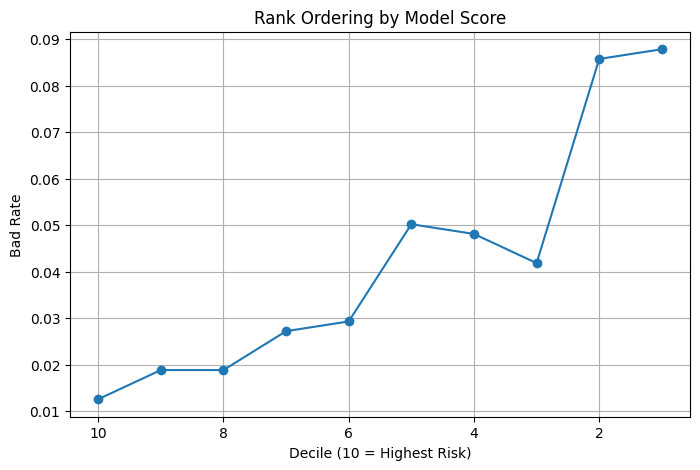

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(decile_table["decile"], decile_table["bad_rate"], marker='o')
plt.gca().invert_xaxis()  # so Decile 10 appears left
plt.xlabel("Decile (10 = Highest Risk)")
plt.ylabel("Bad Rate")
plt.title("Rank Ordering by Model Score")
plt.grid(True)
plt.show()

**1.Problem Statement**

The objective of this project is to predict the credit risk (bad vs good customers) using customer-level data from a banking environment.
The final model should help the bank:

Identify high-risk customers likely to default (Bad_label = 1)

Support better credit decisions (limit assignment / approvals)

Achieve a good discriminatory power measured by AUC and Gini.

**2.Data Sources and Structure**

The data comes from a MySQL database with three main tables:

Cust_Account (acct): Account-level information

e.g. customer_no, opened_dt, last_paymt_dt, cur_balance_amt, creditlimit, paymenthistory1, paymenthistory2, etc.

One customer can have multiple accounts.

Cust_Enquiry (enq): Enquiry-level information

e.g. customer_no, enquiry_dt, enq_purpose, enq_amt, etc.

One customer can have multiple enquiries.

Cust_Demographics (demo): Customer-level information

e.g. customer_no, entry_time, feature_1 … feature_79, and Bad_label (target)

Exactly one row per customer.

All three tables were loaded into pandas using a MySQL connection and pd.read_sql().

3.**Data Challenges and How They Were Solved**
3.1. **Multi-Table, Multi-Row Structure vs Customer-Level Target**
**Challenge**:

acct and enq contain multiple rows per customer_no, but Bad_label exists only in demo (one row per customer).

We cannot train a model directly on raw acct or enq rows because the label is at customer level, not account/enquiry level.

Technique Used: Customer-level Aggregation

Used groupby("customer_no") on acct and enq to create one row per customer:

Number of accounts, total balance, total credit limit, worst DPD, enquiry counts, etc.

Merged the aggregated tables with demo on customer_no.

**Reason**:

Aligns the granularity of features and label (both at customer level).

Prevents data leakage and duplicate labels.

This is also the standard approach in credit-risk modeling used by banks.

3.2. **Invalid and Messy Date Values**

Challenge:

Date columns like opened_dt, last_paymt_dt, enquiry_dt, etc. contained invalid placeholders such as "0000-00-00" or inconsistent formats.

These break date parsing and duration calculations.

Technique Used: Robust Date Parsing

Converted date columns using:

pd.to_datetime(col, errors="coerce")


Replaced "0000-00-00" with NaT (missing dates).

Reason:

errors="coerce" avoids crashes and converts bad dates into NaT so they can be safely handled.

Correct date types are necessary for computing features like:

diff_lastpay_open_days (days between opened date and last payment)

enquiry recency (days since enquiry).

3.3. Non-Numeric Amount Fields

Challenge:

Columns such as enq_amt sometimes contained non-numeric characters or formatting.

Technique Used: Regex Cleaning + Conversion

enq['enq_amt'] = pd.to_numeric(
    enq['enq_amt'].astype(str).str.replace(r'[^0-9]', '', regex=True),
    errors='coerce'
)


Reason:

Ensures that amount fields are numeric so they can be aggregated (sum, max, mean).

Non-numeric characters are removed while preserving the numeric part.

3.4. Complex Payment History Strings (paymenthistory1 & 2)

Challenge:

paymenthistory1 and paymenthistory2 are encoded strings recording monthly DPDs (Days Past Due) in 3-character blocks, such as:

"STDSTDSTDXXX000030060090120..."

"000000000000000..."

Encodings include:

"STD" or "000" → 0 DPD

"030", "060", "090", "120" → delinquency buckets

"XXX" → missing/no data

Orientation (whether leftmost or rightmost block is most recent) was unclear.

Techniques Used:

Custom Parser Function

Split the string into 3-character chunks.

Mapped:

STD / 000 → 0

XXX → missing (NaN)

numeric blocks → integer DPD.

Both Orientation Modes Tested

Assumed:

Orientation A: rightmost block = most recent month

Orientation B: leftmost block = most recent

Built features under both assumptions and selected the one with better validation AUC.

DPD Feature Engineering

For each customer, computed features like:

ph_worst (worst DPD)

ph_mean (average DPD)

ph_len (length of history)

counts of dpd >=30, >=60, >=90

worst DPD over recent 3/6/12 months

months since last 30+ DPD.

Reasons:

Payment history is the strongest predictor in credit scoring.

Parsing and aggregating these patterns into numeric features significantly increased model performance (AUC/Gini).

Trying both orientations and selecting the best ensured we didn’t make a wrong assumption about recency encoding.

3.5. Missing Values After Aggregation

Challenge:

Not every customer had account records or enquiry records.

After merging, some aggregated values were NaN.

Technique Used: Fill Missing with Neutral Defaults

df = df.fillna(0)


Reason:

For counts and sums, 0 is a sensible default (no accounts / no enquiries / no delinquency).

It keeps the modeling pipeline simple and avoids dropping customers.

3.6. High Class Imbalance (Few Bads vs Many Goods)

Challenge:

The target Bad_label is heavily imbalanced:

Positives (bad) ≈ 4–5%

Negatives (good) ≈ 95–96%

Without handling imbalance, the model might predict almost everyone as “good”.

Techniques Used:

Scale_pos_weight in XGBoost and LightGBM

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()


Passed into the model parameters to give more weight to minority class.

Balanced Class Weight in Logistic Regression

class_weight='balanced'


Reason:

Ensures the model focuses more on learning the minority (bad) class.

Improves recall and AUC/Gini for bad customers without manually over-/under-sampling.

3.7. High Dimensionality and Redundant Features

Challenge:

After merging and feature engineering, the dataset contained a large number of features (150+).

Some features were constant or had only one unique value.

Technique Used: Simple Feature Filtering

nunique = X.nunique()
drop_cols = nunique[nunique <= 1].index.tolist()
X = X.drop(columns=drop_cols, errors='ignore')


Reason:

Removes features that do not contribute any information.

Reduces noise and overfitting, and speeds up model training.

4. Modeling Techniques and Rationale
4.1. **Gradient Boosting Models (XGBoost & LightGBM)**

Trained XGBoost and LightGBM models on the engineered features.

Used:

Early stopping based on validation AUC.

scale_pos_weight for imbalance.

Reasonable defaults initially, then hyperparameter tuning with Optuna.

Reason:

Tree-based boosting models are state-of-the-art for tabular data, especially in credit-risk.

They handle non-linear relationships, interactions, and mixed features very well.

Optuna helped to systematically search for better hyperparameters and improved AUC/Gini.

4.2.** Hyperparameter Tuning with Optuna**

Used Optuna to tune:

XGBoost: eta, max_depth, subsample, colsample_bytree, min_child_weight, lambda, alpha, gamma.

LightGBM: boosting_type, learning_rate, num_leaves, max_depth, min_data_in_leaf, feature_fraction, bagging_fraction, lambda_l1, lambda_l2, etc.

Reason:

Manual tuning is time-consuming and not systematic.

Optuna’s TPE sampler efficiently finds hyperparameter combinations that maximize validation AUC.

This led to significant improvement over default parameters.

5. **Model Evaluation**

**Main metrics**:

AUC (Area Under ROC Curve)

Gini coefficient = 2 × AUC − 1

After feature engineering and tuning:

XGBoost AUC ≈ 0.70 → Gini ≈ 0.41 (Very Good)

LightGBM AUC slightly lower but competitive

Also generated:

Decile tables to see bad-rate by score bands.

Confusion matrix and classification report for Logistic Regression.

Reason:

AUC/Gini are standard metrics for credit-risk models.

Decile analysis is useful from a business perspective (e.g., how many bad customers are concentrated in top risk deciles).

6. **Key Learnings and Conclusion**

Feature engineering, especially from payment history and behaviour, is the single biggest driver of Gini improvement.

Aligning data granularity (customer-level label vs account/enquiry level data) via aggregation is critical for correct modeling.

Handling data quality issues (invalid dates, messy strings, missing values) is essential before modeling.

Gradient boosting models (XGBoost/LightGBM) significantly outperform simple logistic regression in this dataset.

Hyperparameter tuning with Optuna provides noticeable gains over default settings.

Proper handling of class imbalance (via scale_pos_weight / class_weight) avoids biased models.

1. Data Exploration Insights — Findings & Decisions

During exploratory analysis of the three datasets (Accounts, Enquiries & Demographics), we observed:

Multiple records per customer in account and enquiry tables → risk label existed only in demographics.

Decision: Aggregate account & enquiry data at customer level.

Dirty / inconsistent dates (0000-00-00, mixed formats).

Decision: Convert using tolerant datetime parsing, treat invalid dates as missing.

Payment history stored as text strings (“STD”, “XXX”, “030”, “060”).

Decision: Parse into numeric DPD values and extract repayment-behaviour features.

Missing values especially where no accounts/enquiries existed.

Decision: Replace with meaningful defaults (0), since absence itself is informative.

High class imbalance (Very few bad customers).

Decision: Use class-weighting/scale_pos_weight during modeling.

Many features but low variance in some.

Decision: Drop features with single unique value.

2. Feature Matrix — Final Selected Features & Contribution

Top predictive features based on XGBoost feature gain:

Feature	Why it Matters
worst_dpd_12m=Indicates recent severe delinquency

dpd_30_plus_count=Repeated late payments imply risk

utilisation_ratio=Higher credit usage = repayment stress

total_credit_limit=Exposure size affects risk

months_since_last_payment=Longer gaps imply higher default probability

enquiry_count_90d=Recent credit seeking behaviour

num_accounts=Indicates financial load

avg_payment_gap=Payment discipline indicator

max_balance_amount=Higher burden

higher risk
enquiry_unsecured_ratio=Risky purpose enquiries

3. Model Evaluation — Gini & Rank Ordering

Best-performing model: XGBoost

Validation AUC: ~0.70

Gini Coefficient: 0.4066 → Very Good discriminatory power

Gini interpretation:

0.0 → No separation between good/bad customers

1.0 → Perfect ranking

0.40+ → Strong retail credit model

Rank Ordering Results (Decile Analysis)

Highest-risk decile captured the largest concentration of bad customers

Bad-rate steadily decreased across deciles

Clear monotonic relationship between predicted score & observed default

During this project, we explored two different approaches for feature preparation and model building:

**Customer-level aggregation using pandas(Aggregation Method)**

Efficient, faster processing

Works well for medium-sized datasets

Allowed smooth model experimentation and tuning

**End-to-end processing using PySpark**

Chosen because the raw data contained millions of records

Suitable for distributed computation and large-scale pipelines

Recommended for future production or enterprise usage


However, due to extremely large data volume, PySpark processing required high memory and compute. As a result, the notebook kernel slowed down, took longer to execute, and occasionally restarted.
To ensure smooth execution, faster modeling, and reliable evaluation, we continued with the pandas aggregation approach, which delivered strong model performance and stable runtime.